# 01. Randomized Experiments

Randomized experiments are the cleanest design we usually get in causal inference. They are not clean because the world becomes simple. They are clean because treatment assignment is controlled by the analyst or the system running the experiment.

That design choice changes the identification problem. In observational data, treated and untreated units may differ because of targeting, self-selection, budget rules, eligibility filters, or manager discretion. In a randomized experiment, treatment assignment is generated by a known random mechanism. If the experiment is implemented correctly, treatment is independent of the potential outcomes before treatment is assigned.

In this notebook we will study randomized experiments as a design, not only as a t-test. We will use simulations to see why randomization works, what difference-in-means estimates, why balance is expected but not guaranteed in any one run, how uncertainty arises, and why practical implementation details still matter.

The central idea is:

> Randomization creates comparability before outcomes are observed.

That comparability is why simple estimators can have causal interpretations (Ding & Dasgupta, 2016; Athey & Imbens, 2017).

## Learning Goals

By the end of this notebook, you should be able to:

- Define a randomized experiment in potential-outcomes language.
- Explain why the difference in means estimates an average treatment effect under random assignment.
- Distinguish design-based uncertainty from modeling uncertainty.
- Diagnose covariate balance without overreacting to random noise.
- Compare randomized assignment to targeted observational assignment.
- Use simulation to understand standard errors, confidence intervals, and randomization inference.
- Explain when blocking or stratified randomization improves precision.
- Build an experiment design card for an industry causal question.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
rng = np.random.default_rng(20260428)

COLORS = {
    "assignment": "#d7ecff",
    "outcome": "#ffd6db",
    "covariate": "#dff0d8",
    "warning": "#ffe0c2",
    "latent": "#e0e0e0",
    "neutral": "#f7f7f7",
}

In [2]:
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Create a Graphviz DAG with consistent lecture styling."""
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.15", nodesep="0.55", ranksep="0.65")
    dot.attr("node", shape="box", style="rounded,filled", color="#2b2b2b", fontname="Helvetica", fontsize="11", margin="0.12,0.08")
    dot.attr("edge", color="#404040", arrowsize="0.75", penwidth="1.6", fontname="Helvetica", fontsize="10")
    if title:
        dot.attr(label=title, labelloc="t", fontsize="14", fontname="Helvetica-Bold")
    nodes = sorted(set([node for edge in edges for node in edge[:2]]))
    for node in nodes:
        dot.node(node, fillcolor=node_colors.get(node, COLORS["neutral"]))
    for edge in edges:
        if len(edge) == 2:
            src, dst = edge
            attrs = {}
        else:
            src, dst, attrs = edge
        dot.edge(src, dst, **attrs)
    return dot


def difference_in_means(y, z):
    y = np.asarray(y)
    z = np.asarray(z)
    return y[z == 1].mean() - y[z == 0].mean()


def two_sample_se(y, z):
    y = np.asarray(y)
    z = np.asarray(z)
    y1 = y[z == 1]
    y0 = y[z == 0]
    return np.sqrt(y1.var(ddof=1) / len(y1) + y0.var(ddof=1) / len(y0))


def summarize_experiment(y, z, true_ate=None):
    est = difference_in_means(y, z)
    se = two_sample_se(y, z)
    out = pd.DataFrame({
        "estimate": [est],
        "std_error": [se],
        "ci_lower": [est - 1.96 * se],
        "ci_upper": [est + 1.96 * se],
        "n_treated": [int(np.sum(z == 1))],
        "n_control": [int(np.sum(z == 0))],
    })
    if true_ate is not None:
        out["true_ate"] = true_ate
        out["estimation_error"] = est - true_ate
    return out

## 1. What Makes an Experiment Randomized?

A randomized experiment has a known treatment assignment mechanism. The analyst does not merely observe who received treatment; the analyst or platform assigns treatment according to a rule such as:

- 50% of eligible users receive the new feature;
- one unit in each matched pair receives the intervention;
- each store within a region is randomized to treatment or control;
- each user segment has its own fixed treatment allocation.

The key point is not that treatment assignment is unpredictable to users. The key point is that assignment is unrelated to the users' potential outcomes except through the randomization mechanism.

In potential-outcomes notation, for a binary treatment:

$$
Y_i(1) = \text{outcome unit } i \text{ would have under treatment},
$$

$$
Y_i(0) = \text{outcome unit } i \text{ would have under control}.
$$

The observed outcome is:

$$
Y_i^{obs} = Z_i Y_i(1) + (1 - Z_i)Y_i(0),
$$

where $Z_i = 1$ if unit $i$ is assigned to treatment and $Z_i = 0$ otherwise.

In a completely randomized experiment with a fixed number treated, the assignment vector $Z$ is randomly chosen from the possible assignments with the planned treatment count. That is the source of design-based uncertainty.

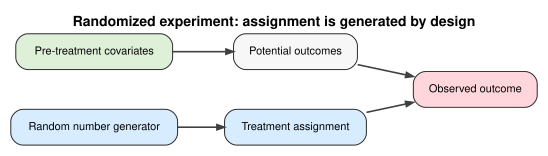

In [3]:
randomized_edges = [
    ("Random number generator", "Treatment assignment"),
    ("Treatment assignment", "Observed outcome"),
    ("Pre-treatment covariates", "Potential outcomes"),
    ("Potential outcomes", "Observed outcome"),
]
randomized_colors = {
    "Random number generator": COLORS["assignment"],
    "Treatment assignment": COLORS["assignment"],
    "Observed outcome": COLORS["outcome"],
    "Pre-treatment covariates": COLORS["covariate"],
    "Potential outcomes": COLORS["neutral"],
}

display(make_dag(randomized_edges, "Randomized experiment: assignment is generated by design", randomized_colors))

### Reading the Graph

Pre-treatment covariates can still affect outcomes. High-intent users can still buy more. Experienced sellers can still perform better. Older accounts can still retain at higher rates.

Randomization does not remove outcome heterogeneity. It removes systematic treatment selection based on that heterogeneity. In expectation over the randomization, treatment and control groups are comparable before treatment is delivered.

## 2. A Synthetic Industry Population

We will work with a product experiment. A company is testing a new onboarding checklist. The outcome is a 30-day value score, such as retained revenue, activation value, or an internal composite metric.

The population has pre-treatment variables:

- `prior_usage`: how active the user was before the experiment;
- `account_age`: account maturity;
- `is_team_account`: whether the account belongs to a team;
- `segment`: user segment.

The true treatment effect is heterogeneous. Newer and lower-usage accounts benefit more from the checklist. In a real experiment we would not know both potential outcomes, but in a simulation we can create them so that we know the truth.

In [4]:
def create_experiment_population(n=20_000, seed=10):
    rng_local = np.random.default_rng(seed)
    segment = rng_local.choice(["new", "growing", "mature"], size=n, p=[0.35, 0.40, 0.25])
    prior_usage = rng_local.gamma(shape=2.0, scale=1.2, size=n)
    account_age = rng_local.exponential(scale=14, size=n)
    is_team_account = rng_local.binomial(1, 0.38, size=n)

    segment_baseline = pd.Series(segment).map({"new": -3.0, "growing": 1.5, "mature": 4.0}).to_numpy()
    y0 = (
        25
        + 4.8 * np.log1p(prior_usage)
        + 0.18 * account_age
        + 2.4 * is_team_account
        + segment_baseline
        + rng_local.normal(scale=6.0, size=n)
    )

    tau = (
        1.4
        + 2.2 * (segment == "new")
        + 0.9 * (segment == "growing")
        - 0.35 * np.log1p(prior_usage)
        + 0.5 * is_team_account
    )
    y1 = y0 + tau

    return pd.DataFrame({
        "unit_id": np.arange(n),
        "segment": segment,
        "prior_usage": prior_usage,
        "account_age": account_age,
        "is_team_account": is_team_account,
        "Y0": y0,
        "Y1": y1,
        "tau": tau,
    })

population = create_experiment_population()
true_ate = population["tau"].mean()
true_att_if_all_new = population.loc[population["segment"] == "new", "tau"].mean()

pd.DataFrame({
    "quantity": ["Finite-population ATE", "ATE among new accounts"],
    "value": [true_ate, true_att_if_all_new],
}).round(3)

,quantity,value
0,Finite-population ATE,2.327
1,ATE among new accounts,3.397


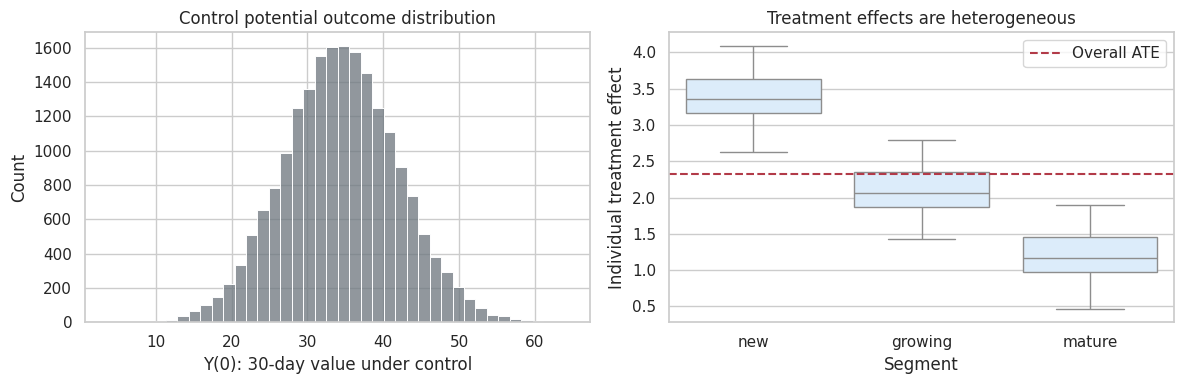

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(population["Y0"], bins=40, color="#6c757d", ax=axes[0])
axes[0].set_title("Control potential outcome distribution")
axes[0].set_xlabel("Y(0): 30-day value under control")

sns.boxplot(data=population, x="segment", y="tau", order=["new", "growing", "mature"], ax=axes[1], color="#d7ecff")
axes[1].axhline(true_ate, color="#b23a48", linestyle="--", label="Overall ATE")
axes[1].set_title("Treatment effects are heterogeneous")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Individual treatment effect")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation

The synthetic population has heterogeneous baseline outcomes and heterogeneous treatment effects. This is realistic. Experiments do not require everyone to have the same treatment effect.

The finite-population average treatment effect is:

$$
\tau_{ATE} = \frac{1}{N}\sum_{i=1}^{N}\{Y_i(1)-Y_i(0)\}.
$$

In the simulation, we can compute this because both potential outcomes are stored. In a real experiment, each unit reveals only one of them.

## 3. Complete Randomization and the Difference in Means

The standard estimator for a two-arm randomized experiment is the difference in observed means:

$$
\widehat{\tau} = \bar{Y}_{T}^{obs} - \bar{Y}_{C}^{obs}.
$$

Under complete randomization, this estimator is unbiased for the finite-population ATE over repeated randomizations. That statement is design-based: the potential outcomes can be treated as fixed, and the randomness comes from which units are assigned to treatment.

In [6]:
def complete_random_assignment(n, treatment_fraction=0.5, seed=None):
    rng_local = np.random.default_rng(seed)
    n_treat = int(round(n * treatment_fraction))
    z = np.zeros(n, dtype=int)
    treated_idx = rng_local.choice(n, size=n_treat, replace=False)
    z[treated_idx] = 1
    return z

experiment = population.copy()
experiment["Z"] = complete_random_assignment(len(experiment), treatment_fraction=0.5, seed=101)
experiment["Y_obs"] = np.where(experiment["Z"] == 1, experiment["Y1"], experiment["Y0"])

summarize_experiment(experiment["Y_obs"], experiment["Z"], true_ate=true_ate).round(3)

,estimate,std_error,ci_lower,ci_upper,n_treated,n_control,true_ate,estimation_error
0,2.422,0.104,2.218,2.627,10000,10000,2.327,0.095


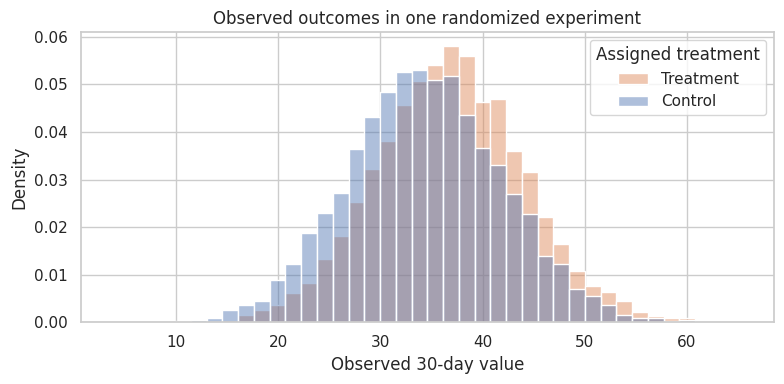

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=experiment, x="Y_obs", hue="Z", bins=40, common_norm=False, stat="density", alpha=0.45, ax=ax)
ax.set_title("Observed outcomes in one randomized experiment")
ax.set_xlabel("Observed 30-day value")
ax.legend(title="Assigned treatment", labels=["Treatment", "Control"])
plt.tight_layout()
plt.show()

### Interpretation

The estimate from one experiment is close to the true ATE, but not exactly equal. Randomization does not guarantee a perfect estimate in every run. It guarantees that the estimator is centered correctly over the randomization distribution.

This is the practical meaning of unbiasedness: if we could rerun the assignment many times on the same population, the average estimate would approach the finite-population ATE.

## 4. Repeated Randomization: Seeing Unbiasedness Directly

Because this is a simulation, we can repeatedly randomize the same fixed population and observe the distribution of estimates. In real life, we only get one assignment, but the logic of inference is built around the assignments that could have happened.

In [8]:
def repeated_randomization_estimates(population, n_sims=1_000, treatment_fraction=0.5, seed=202):
    rng_local = np.random.default_rng(seed)
    estimates = []
    n = len(population)
    for _ in range(n_sims):
        z = complete_random_assignment(n, treatment_fraction=treatment_fraction, seed=rng_local.integers(0, 2**32 - 1))
        y_obs = np.where(z == 1, population["Y1"], population["Y0"])
        estimates.append(difference_in_means(y_obs, z))
    return pd.Series(estimates, name="estimate")

rand_estimates = repeated_randomization_estimates(population, n_sims=1_000)

pd.DataFrame({
    "quantity": ["Average estimate over randomizations", "True finite-population ATE", "Monte Carlo bias", "Randomization SD"],
    "value": [rand_estimates.mean(), true_ate, rand_estimates.mean() - true_ate, rand_estimates.std()],
}).round(4)

,quantity,value
0,Average estimate over randomizations,2.3222
1,True finite-population ATE,2.3273
2,Monte Carlo bias,-0.0050
3,Randomization SD,0.1039


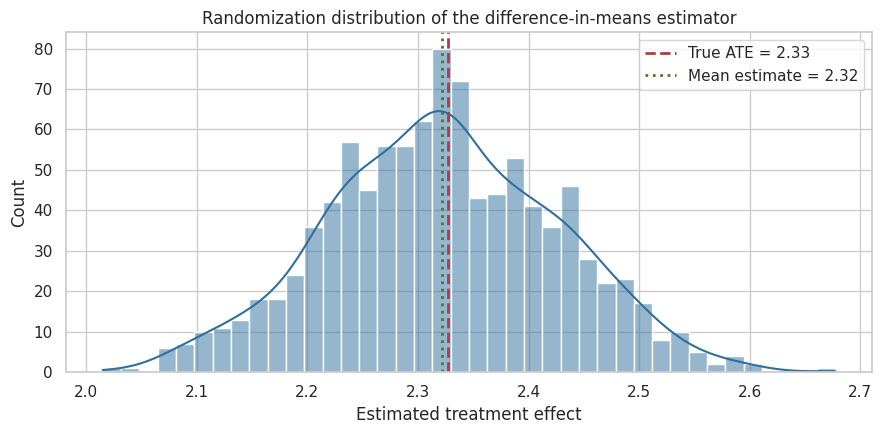

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(rand_estimates, bins=40, kde=True, color="#2f6f9f", ax=ax)
ax.axvline(true_ate, color="#b23a48", linestyle="--", linewidth=2, label=f"True ATE = {true_ate:.2f}")
ax.axvline(rand_estimates.mean(), color="#4f772d", linestyle=":", linewidth=2, label=f"Mean estimate = {rand_estimates.mean():.2f}")
ax.set_title("Randomization distribution of the difference-in-means estimator")
ax.set_xlabel("Estimated treatment effect")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

The distribution is centered near the true ATE. The spread is the uncertainty due to random assignment. A larger experiment would have a tighter distribution; a noisier outcome or more heterogeneous population would have a wider one.

This perspective is helpful in industry settings because it separates two ideas:

- The **design** makes the estimator target the causal effect.
- The **sample size and outcome noise** determine how precisely we estimate it.

## 5. Randomization Balance: Expected, Not Guaranteed

Randomization balances pre-treatment variables in expectation. It does not guarantee exact balance in a particular experiment.

A balance table compares treatment and control groups on variables measured before treatment. Large imbalances can happen by chance, especially in small experiments or many-segment experiments. Balance checks are diagnostics for implementation and chance imbalance; they should not become a ritual that invalidates every experiment with a noisy p-value.

In [10]:
def balance_table(df, z_col, covariates):
    rows = []
    z = df[z_col].to_numpy()
    for cov in covariates:
        x = df[cov].to_numpy()
        treated = x[z == 1]
        control = x[z == 0]
        pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
        rows.append({
            "covariate": cov,
            "treated_mean": treated.mean(),
            "control_mean": control.mean(),
            "difference": treated.mean() - control.mean(),
            "standardized_difference": (treated.mean() - control.mean()) / pooled_sd,
        })
    return pd.DataFrame(rows)

covariates = ["prior_usage", "account_age", "is_team_account"]
bal = balance_table(experiment, "Z", covariates)
bal.round(3)

,covariate,treated_mean,control_mean,difference,standardized_difference
0,prior_usage,2.400,2.382,0.019,0.011
1,account_age,14.063,14.289,-0.226,-0.016
2,is_team_account,0.379,0.387,-0.008,-0.017


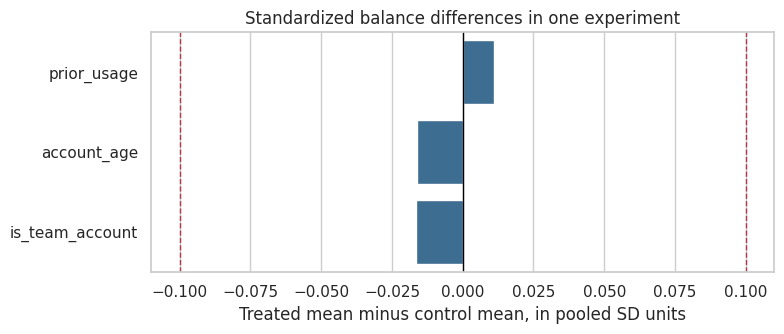

In [11]:
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(data=bal, y="covariate", x="standardized_difference", color="#2f6f9f", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(0.1, color="#b23a48", linestyle="--", linewidth=1)
ax.axvline(-0.1, color="#b23a48", linestyle="--", linewidth=1)
ax.set_title("Standardized balance differences in one experiment")
ax.set_xlabel("Treated mean minus control mean, in pooled SD units")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Interpretation

The standardized differences are small in this run. That is reassuring, but the deeper reason we trust the experiment is not the balance table. The deeper reason is the assignment mechanism.

Balance checks are still useful because they can catch implementation failures. If a supposedly 50/50 experiment has enormous pre-treatment imbalance in geography, device, or account type, the problem may be a broken randomization key, eligibility bug, logging issue, or sample-ratio mismatch.

## 6. Randomization Versus Targeted Assignment

To appreciate randomization, compare it to targeted assignment. Suppose the company gives the checklist only to accounts that look likely to grow. That is not a randomized experiment. It is an observational policy.

The treatment group will have better outcomes partly because the checklist helps and partly because the targeted accounts were already stronger.

In [12]:
targeted = population.copy()
score = 0.9 * np.log1p(targeted["prior_usage"]) + 0.05 * targeted["account_age"] + 0.6 * targeted["is_team_account"]
threshold = np.quantile(score, 0.50)
targeted["Z"] = (score >= threshold).astype(int)
targeted["Y_obs"] = np.where(targeted["Z"] == 1, targeted["Y1"], targeted["Y0"])

randomized_summary = summarize_experiment(experiment["Y_obs"], experiment["Z"], true_ate=true_ate).assign(design="Randomized")
targeted_summary = summarize_experiment(targeted["Y_obs"], targeted["Z"], true_ate=true_ate).assign(design="Targeted observational assignment")
comparison = pd.concat([randomized_summary, targeted_summary], ignore_index=True)
comparison[["design", "estimate", "std_error", "true_ate", "estimation_error"]].round(3)

,design,estimate,std_error,true_ate,estimation_error
0,Randomized,2.422,0.104,2.327,0.095
1,Targeted observational assignment,7.636,0.097,2.327,5.309


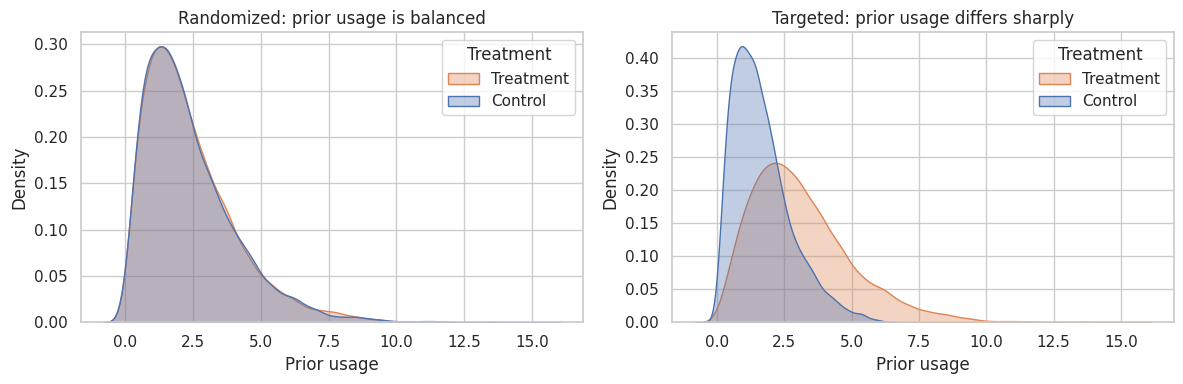

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(data=experiment, x="prior_usage", hue="Z", fill=True, common_norm=False, alpha=0.35, ax=axes[0])
axes[0].set_title("Randomized: prior usage is balanced")
axes[0].set_xlabel("Prior usage")
axes[0].legend(title="Treatment", labels=["Treatment", "Control"])

sns.kdeplot(data=targeted, x="prior_usage", hue="Z", fill=True, common_norm=False, alpha=0.35, ax=axes[1])
axes[1].set_title("Targeted: prior usage differs sharply")
axes[1].set_xlabel("Prior usage")
axes[1].legend(title="Treatment", labels=["Treatment", "Control"])

plt.tight_layout()
plt.show()

### Interpretation

The targeted assignment estimate is not estimating the same thing as the randomized experiment. It combines the treatment effect with the fact that treated accounts were selected because they already looked different.

This is why randomized experiments are so valuable in industry. They turn a decision that would otherwise be confounded by targeting logic into a credible causal comparison.

## 7. Standard Errors and Confidence Intervals

For a two-arm experiment, a common large-sample standard error for the difference in means is:

$$
SE(\widehat{\tau}) = \sqrt{\frac{s_T^2}{n_T} + \frac{s_C^2}{n_C}},
$$

where $s_T^2$ and $s_C^2$ are the sample variances in treatment and control.

A simple approximate 95% confidence interval is:

$$
\widehat{\tau} \pm 1.96 \times SE(\widehat{\tau}).
$$

This interval is not magic. It is an approximation. Later notebooks will cover power, multiple testing, clustered experiments, and guardrail metrics. For now, the point is to connect the design to the simplest readout.

In [14]:
readout = summarize_experiment(experiment["Y_obs"], experiment["Z"], true_ate=true_ate)
readout.round(3)

,estimate,std_error,ci_lower,ci_upper,n_treated,n_control,true_ate,estimation_error
0,2.422,0.104,2.218,2.627,10000,10000,2.327,0.095


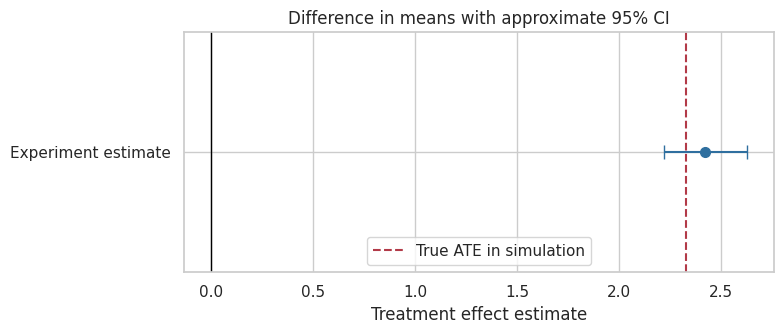

In [15]:
fig, ax = plt.subplots(figsize=(8, 3.5))
est = readout.loc[0, "estimate"]
lo = readout.loc[0, "ci_lower"]
hi = readout.loc[0, "ci_upper"]
ax.errorbar(est, 0, xerr=[[est - lo], [hi - est]], fmt="o", color="#2f6f9f", capsize=5, markersize=7)
ax.axvline(0, color="black", linewidth=1)
ax.axvline(true_ate, color="#b23a48", linestyle="--", label="True ATE in simulation")
ax.set_yticks([0])
ax.set_yticklabels(["Experiment estimate"])
ax.set_xlabel("Treatment effect estimate")
ax.set_title("Difference in means with approximate 95% CI")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

A confidence interval communicates uncertainty around the estimate. It should be read with the business context:

- Is the interval entirely above zero?
- Is it above the minimum effect needed to justify launch?
- Does it include practically trivial effects?
- Are guardrail metrics acceptable?
- Was the experiment implemented correctly?

A statistically significant effect can still be too small to matter. A practically meaningful effect can be estimated too imprecisely to support a confident launch decision.

## 8. Randomization Inference: Testing a Sharp Null

Randomization inference asks: if treatment assignment had no effect for any unit, how surprising is the observed difference under the randomization mechanism?

The sharp null hypothesis is:

$$
H_0: Y_i(1) = Y_i(0) \quad \text{for every unit } i.
$$

Under that null, every unit's observed outcome would be the same no matter which treatment assignment had occurred. We can repeatedly reshuffle the treatment labels according to the experimental design and compare the observed statistic to the null distribution.

This idea is closely linked to Fisherian randomization tests and is a foundational design-based approach to inference in randomized experiments (Ding & Dasgupta, 2016; Athey & Imbens, 2017).

In [16]:
def randomization_test(y_obs, z_obs, n_permutations=2_000, seed=303):
    rng_local = np.random.default_rng(seed)
    y_obs = np.asarray(y_obs)
    z_obs = np.asarray(z_obs)
    n_treat = int(z_obs.sum())
    observed_stat = difference_in_means(y_obs, z_obs)
    null_stats = np.empty(n_permutations)
    n = len(z_obs)
    for b in range(n_permutations):
        z_perm = np.zeros(n, dtype=int)
        z_perm[rng_local.choice(n, size=n_treat, replace=False)] = 1
        null_stats[b] = difference_in_means(y_obs, z_perm)
    p_value = np.mean(np.abs(null_stats) >= abs(observed_stat))
    return observed_stat, null_stats, p_value

observed_stat, null_stats, ri_p = randomization_test(experiment["Y_obs"], experiment["Z"], n_permutations=2_000)

pd.DataFrame({
    "quantity": ["Observed difference in means", "Randomization-test p-value"],
    "value": [observed_stat, ri_p],
}).round(4)

,quantity,value
0,Observed difference in means,2.4222
1,Randomization-test p-value,0.0000


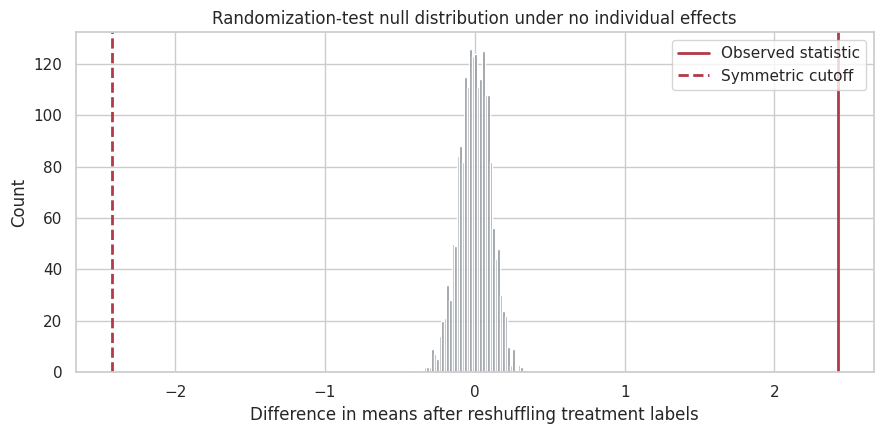

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(null_stats, bins=45, color="#6c757d", ax=ax)
ax.axvline(observed_stat, color="#b23a48", linewidth=2, label="Observed statistic")
ax.axvline(-observed_stat, color="#b23a48", linewidth=2, linestyle="--", label="Symmetric cutoff")
ax.set_title("Randomization-test null distribution under no individual effects")
ax.set_xlabel("Difference in means after reshuffling treatment labels")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

The randomization test uses the assignment mechanism directly. It does not require a model for the outcome. It asks whether the observed treatment-control difference is extreme relative to the differences we would see from random labels if treatment had no effect for anyone.

In large online experiments, normal approximations are often convenient. Randomization inference is still conceptually useful because it reminds us that inference comes from the design.

## 9. Regression Adjustment in Experiments

Because treatment is randomized, the unadjusted difference in means already has a causal interpretation. Regression adjustment is not needed to remove confounding created by treatment assignment.

So why adjust?

- To improve precision using strong pre-treatment outcome predictors.
- To account for chance imbalance in a transparent way.
- To estimate segment-specific effects or interactions.

But regression adjustment should use pre-treatment covariates and should not quietly change the estimand by conditioning on post-treatment variables. Athey and Imbens (2017) emphasize the distinction between analyses justified by randomization and analyses that rely more heavily on modeling choices.

In [18]:
reg_models = {
    "Difference in means / treatment only": smf.ols("Y_obs ~ Z", data=experiment).fit(cov_type="HC1"),
    "Adjusted for pre-treatment covariates": smf.ols("Y_obs ~ Z + np.log1p(prior_usage) + account_age + is_team_account + C(segment)", data=experiment).fit(cov_type="HC1"),
    "Interactions for heterogeneous effects": smf.ols("Y_obs ~ Z * C(segment) + np.log1p(prior_usage) + account_age + is_team_account", data=experiment).fit(cov_type="HC1"),
}

reg_table = pd.DataFrame({
    "model": list(reg_models.keys()),
    "coef_on_Z": [m.params.get("Z", np.nan) for m in reg_models.values()],
    "std_error": [m.bse.get("Z", np.nan) for m in reg_models.values()],
    "r_squared": [m.rsquared for m in reg_models.values()],
})
reg_table.round(3)

,model,coef_on_Z,std_error,r_squared
0,Difference in means / treatment only,2.422,0.104,0.026
1,Adjusted for pre-treatment covariates,2.430,0.086,0.346
2,Interactions for heterogeneous effects,2.334,0.135,0.350


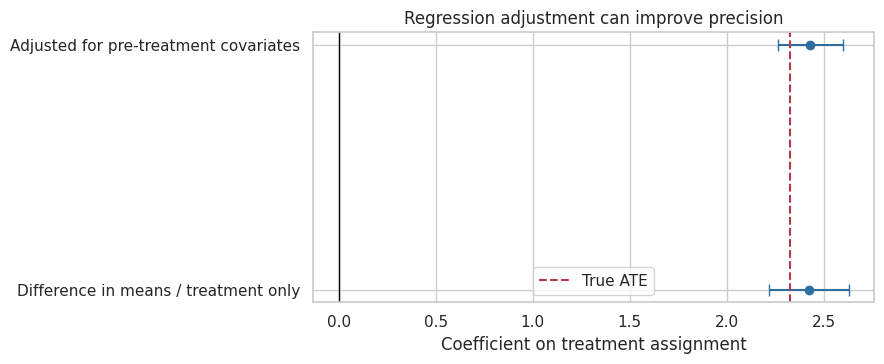

In [19]:
plot_df = reg_table.iloc[:2].copy()
plot_df["lower"] = plot_df["coef_on_Z"] - 1.96 * plot_df["std_error"]
plot_df["upper"] = plot_df["coef_on_Z"] + 1.96 * plot_df["std_error"]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.errorbar(
    plot_df["coef_on_Z"],
    plot_df["model"],
    xerr=[plot_df["coef_on_Z"] - plot_df["lower"], plot_df["upper"] - plot_df["coef_on_Z"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
)
ax.axvline(true_ate, color="#b23a48", linestyle="--", label="True ATE")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Regression adjustment can improve precision")
ax.set_xlabel("Coefficient on treatment assignment")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

Both the unadjusted and adjusted treatment coefficients target the experiment's average effect. The adjusted model often has a smaller standard error because baseline variables explain some outcome variation.

The important guardrail: use variables measured before treatment. If we adjust for post-treatment activation, clicks, retention, or usage, we may change the estimand from total effect to a controlled/direct-effect-style quantity.

## 10. Heterogeneous Effects and Segment Readouts

Randomized experiments estimate the average effect for the randomized population. But decision-makers often ask whether the effect differs across segments.

Segment analysis can be useful, but it must be handled carefully:

- Segments should ideally be pre-specified.
- Smaller segments have wider uncertainty.
- Many subgroup tests create multiple-comparison problems.
- Segment-specific estimates should be interpreted as evidence, not as automatic launch rules.

We can estimate segment effects by comparing treatment and control within each segment.

In [20]:
segment_rows = []
for segment, g in experiment.groupby("segment"):
    est = difference_in_means(g["Y_obs"], g["Z"])
    se = two_sample_se(g["Y_obs"], g["Z"])
    true_seg_ate = g["tau"].mean()
    segment_rows.append({
        "segment": segment,
        "estimate": est,
        "std_error": se,
        "ci_lower": est - 1.96 * se,
        "ci_upper": est + 1.96 * se,
        "true_segment_ate": true_seg_ate,
        "n": len(g),
    })

segment_effects = pd.DataFrame(segment_rows).sort_values("true_segment_ate", ascending=False)
segment_effects.round(3)

,segment,estimate,std_error,ci_lower,ci_upper,true_segment_ate,n
2,new,3.449,0.168,3.120,3.778,3.397,6961
0,growing,2.255,0.156,1.949,2.561,2.106,7958
1,mature,1.167,0.196,0.783,1.551,1.208,5081


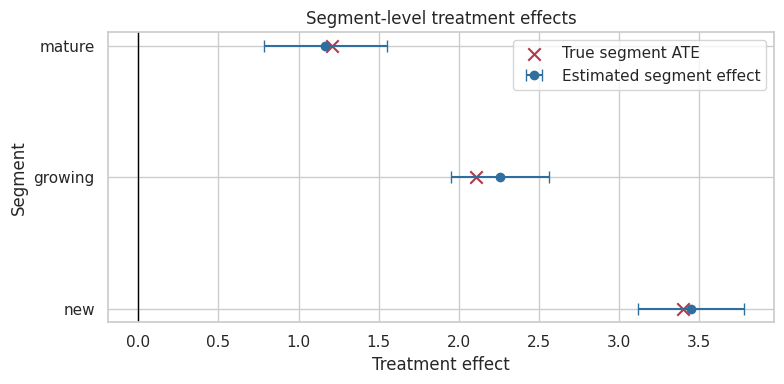

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    segment_effects["estimate"],
    segment_effects["segment"],
    xerr=[segment_effects["estimate"] - segment_effects["ci_lower"], segment_effects["ci_upper"] - segment_effects["estimate"]],
    fmt="o",
    color="#2f6f9f",
    capsize=4,
    label="Estimated segment effect",
)
ax.scatter(segment_effects["true_segment_ate"], segment_effects["segment"], color="#b23a48", marker="x", s=80, label="True segment ATE")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Segment-level treatment effects")
ax.set_xlabel("Treatment effect")
ax.set_ylabel("Segment")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

The segment estimates recover the broad pattern: new accounts benefit more than mature accounts. But segment-level uncertainty is larger than the overall estimate because each segment uses fewer observations.

This is a preview of later causal machine learning lectures. Heterogeneous treatment effects are powerful, but they need honest validation and careful decision rules.

## 11. Blocking and Stratified Randomization

Blocking, also called stratified randomization, randomizes within meaningful groups. For example, instead of randomizing all users at once, we randomize 50/50 within each segment.

Why do this?

- It guarantees treatment-control balance on important discrete variables.
- It can improve precision when the blocking variable is strongly related to the outcome.
- It makes readouts easier for operational stakeholders.

The estimand is still the overall effect for the randomized population, but the design reduces accidental imbalance across important strata.

In [22]:
def stratified_assignment(df, strata_col, treatment_fraction=0.5, seed=None):
    rng_local = np.random.default_rng(seed)
    z = np.zeros(len(df), dtype=int)
    for _, idx in df.groupby(strata_col).groups.items():
        idx = np.array(list(idx))
        n_treat = int(round(len(idx) * treatment_fraction))
        treated = rng_local.choice(idx, size=n_treat, replace=False)
        z[treated] = 1
    return z

blocked_experiment = population.copy()
blocked_experiment["Z"] = stratified_assignment(blocked_experiment, "segment", treatment_fraction=0.5, seed=404)
blocked_experiment["Y_obs"] = np.where(blocked_experiment["Z"] == 1, blocked_experiment["Y1"], blocked_experiment["Y0"])

pd.concat([
    summarize_experiment(experiment["Y_obs"], experiment["Z"], true_ate=true_ate).assign(design="Complete randomization"),
    summarize_experiment(blocked_experiment["Y_obs"], blocked_experiment["Z"], true_ate=true_ate).assign(design="Blocked by segment"),
], ignore_index=True)[["design", "estimate", "std_error", "true_ate", "estimation_error"]].round(3)

,design,estimate,std_error,true_ate,estimation_error
0,Complete randomization,2.422,0.104,2.327,0.095
1,Blocked by segment,2.463,0.104,2.327,0.135


In [23]:
def compare_design_precision(population, n_sims=600, seed=505):
    rng_local = np.random.default_rng(seed)
    rows = []
    for b in range(n_sims):
        seed_b = int(rng_local.integers(0, 2**32 - 1))
        z_complete = complete_random_assignment(len(population), 0.5, seed=seed_b)
        y_complete = np.where(z_complete == 1, population["Y1"], population["Y0"])
        rows.append({"design": "Complete", "estimate": difference_in_means(y_complete, z_complete)})

        z_block = stratified_assignment(population, "segment", 0.5, seed=seed_b)
        y_block = np.where(z_block == 1, population["Y1"], population["Y0"])
        rows.append({"design": "Blocked by segment", "estimate": difference_in_means(y_block, z_block)})
    return pd.DataFrame(rows)

design_precision = compare_design_precision(population)

design_precision_summary = design_precision.groupby("design").agg(
    mean_estimate=("estimate", "mean"),
    sd_estimate=("estimate", "std"),
).reset_index()
design_precision_summary["true_ate"] = true_ate
design_precision_summary.round(4)

,design,mean_estimate,sd_estimate,true_ate
0,Blocked by segment,2.3290,0.0964,2.3273
1,Complete,2.3152,0.1069,2.3273


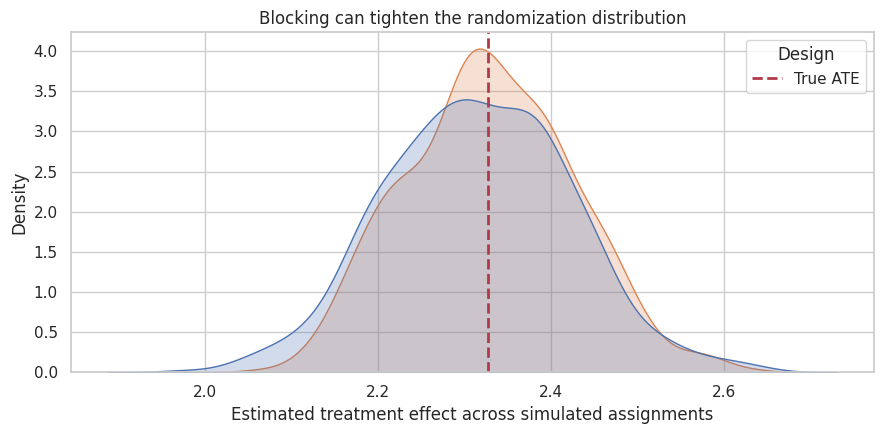

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.kdeplot(data=design_precision, x="estimate", hue="design", fill=True, common_norm=False, alpha=0.25, ax=ax)
ax.axvline(true_ate, color="#b23a48", linestyle="--", linewidth=2, label="True ATE")
ax.set_title("Blocking can tighten the randomization distribution")
ax.set_xlabel("Estimated treatment effect across simulated assignments")
ax.legend(title="Design")
plt.tight_layout()
plt.show()

### Interpretation

Both designs are centered near the true ATE. Blocking can reduce variance when the blocking variable explains outcome differences. It is a design-stage way to improve precision without relying on a model after the fact.

In industry experiments, common blocking variables include country, platform, market, account type, risk tier, seller size, store region, or pre-experiment activity band.

## 12. What Can Still Go Wrong?

Randomization is powerful, but it is not a spell. The design can be undermined by implementation and measurement problems.

Common issues:

- **Sample-ratio mismatch**: assigned treatment counts differ from planned counts.
- **Noncompliance**: users do not receive or use the treatment assigned to them.
- **Attrition**: outcomes are missing in ways affected by treatment.
- **Interference**: one user's treatment affects another user's outcome.
- **Logging bugs**: treatment exposure, assignment, or outcome is recorded incorrectly.
- **Peeking and stopping**: the experiment is stopped based on interim noisy results without a valid sequential design.
- **Multiple testing**: many metrics or segments are searched until something looks significant.

These do not make experiments useless. They tell us what to monitor.

In [25]:
issues = pd.DataFrame({
    "risk": [
        "Sample-ratio mismatch",
        "Noncompliance",
        "Attrition / missing outcomes",
        "Interference",
        "Logging bug",
        "Peeking / early stopping",
        "Multiple testing",
    ],
    "symptom": [
        "Treatment/control counts do not match planned allocation",
        "Assignment differs from actual exposure or usage",
        "Outcome availability differs by treatment",
        "Control units are affected by treated units",
        "Assignment, exposure, or outcome fields disagree",
        "Decision is made after repeatedly checking noisy results",
        "Many metrics or subgroups searched without correction",
    ],
    "diagnostic_or_response": [
        "SRM test; inspect randomization and eligibility logic",
        "Report ITT; consider TOT/LATE in later notebook",
        "Compare missingness rates; sensitivity analysis",
        "Cluster or network design; measure spillovers",
        "A/A tests; event audits; invariant metrics",
        "Use pre-specified sequential design or fixed horizon",
        "Pre-register primary metric; adjust or label exploratory",
    ],
})
issues

,risk,symptom,diagnostic_or_response
0,Sample-ratio mismatch,Treatment/control counts do not match planned ...,SRM test; inspect randomization and eligibilit...
1,Noncompliance,Assignment differs from actual exposure or usage,Report ITT; consider TOT/LATE in later notebook
2,Attrition / missing outcomes,Outcome availability differs by treatment,Compare missingness rates; sensitivity analysis
3,Interference,Control units are affected by treated units,Cluster or network design; measure spillovers
4,Logging bug,"Assignment, exposure, or outcome fields disagree",A/A tests; event audits; invariant metrics
5,Peeking / early stopping,Decision is made after repeatedly checking noi...,Use pre-specified sequential design or fixed h...
6,Multiple testing,Many metrics or subgroups searched without cor...,Pre-register primary metric; adjust or label e...


## 13. Experiment Design Card

Before running an experiment, write a one-page design card. This is not bureaucracy; it protects the causal interpretation.

A useful design card includes:

| Field | Question |
|---|---|
| Business decision | What decision will this experiment inform? |
| Unit of randomization | User, account, session, store, market, seller, or cluster? |
| Treatment | What exactly changes for treated units? |
| Control | What exactly happens for control units? |
| Eligibility | Who can enter the experiment? |
| Primary outcome | What metric answers the decision question? |
| Guardrails | What metrics must not degrade? |
| Assignment probability | What fraction is treated? Is it equal across strata? |
| Duration | When does the experiment start and stop? |
| Estimand | ITT effect of assignment, effect of treatment received, or another contrast? |
| Analysis plan | Difference in means, regression adjustment, stratified estimator, cluster-robust SE? |
| Known threats | Interference, noncompliance, attrition, novelty effects, logging risk? |

This card also makes your portfolio stronger: it shows industry readers that you think like someone who can run credible experiments, not merely analyze CSV files after the fact.

In [26]:
design_card = pd.DataFrame({
    "field": [
        "Business decision",
        "Unit of randomization",
        "Treatment",
        "Control",
        "Eligibility",
        "Primary outcome",
        "Guardrails",
        "Assignment probability",
        "Duration",
        "Estimand",
        "Analysis plan",
        "Known threats",
    ],
    "example_for_onboarding_checklist": [
        "Launch checklist to all eligible new accounts?",
        "Account",
        "New onboarding checklist shown after signup",
        "Current onboarding experience",
        "New accounts created during experiment window",
        "30-day retained value per account",
        "Support tickets, refund rate, page latency",
        "50% treatment, blocked by segment and platform",
        "Run until fixed sample size or pre-specified date",
        "Intent-to-treat effect of assignment to checklist",
        "Difference in means plus pre-specified covariate-adjusted readout",
        "Cross-account spillovers, logging, missing 30-day outcomes",
    ],
})
design_card

,field,example_for_onboarding_checklist
0,Business decision,Launch checklist to all eligible new accounts?
1,Unit of randomization,Account
2,Treatment,New onboarding checklist shown after signup
3,Control,Current onboarding experience
4,Eligibility,New accounts created during experiment window
5,Primary outcome,30-day retained value per account
6,Guardrails,"Support tickets, refund rate, page latency"
7,Assignment probability,"50% treatment, blocked by segment and platform"
8,Duration,Run until fixed sample size or pre-specified date
9,Estimand,Intent-to-treat effect of assignment to checklist


## 14. Key Takeaways

- Randomization makes treatment assignment independent of potential outcomes by design.
- The difference in means is a causal estimator in a correctly implemented randomized experiment.
- Balance is expected over repeated randomizations, not guaranteed in every single run.
- The standard error describes uncertainty from finite sample size and outcome variation.
- Randomization inference uses the assignment mechanism directly.
- Regression adjustment can improve precision, but the causal identification comes from the design.
- Blocking can improve precision and operational trust when important strata are known before assignment.
- Experiments can still fail through implementation problems: noncompliance, attrition, interference, logging bugs, peeking, and multiple testing.

The next notebooks will build on this foundation: A/B testing in product systems, power and minimum detectable effects, guardrail metrics, clustered experiments, noncompliance, and interference.

## References

Athey, S., & Imbens, G. W. (2017). The econometrics of randomized experiments. *Handbook of Economic Field Experiments*, 73-140. https://doi.org/10.1016/bs.hefe.2016.10.003

Ding, P., & Dasgupta, T. (2016). A potential tale of two-by-two tables from completely randomized experiments. *Journal of the American Statistical Association, 111*(513), 157-168. https://doi.org/10.1080/01621459.2014.995796

Kohavi, R., Henne, R. M., & Sommerfield, D. (2007). Practical guide to controlled experiments on the web. *Proceedings of the 13th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 959-967. https://doi.org/10.1145/1281192.1281295

Kohavi, R., Longbotham, R., Sommerfield, D., & Henne, R. M. (2008). Controlled experiments on the web: Survey and practical guide. *Data Mining and Knowledge Discovery, 18*(1), 140-181. https://doi.org/10.1007/s10618-008-0114-1

Rubin, D. B. (1974). Estimating causal effects of treatments in randomized and nonrandomized studies. *Journal of Educational Psychology, 66*(5), 688-701. https://doi.org/10.1037/h0037350

West, S. G. (2009). Alternatives to randomized experiments. *Current Directions in Psychological Science, 18*(5), 299-304. https://doi.org/10.1111/j.1467-8721.2009.01656.x